In [1]:
%load_ext autoreload
%autoreload

In [2]:
# import numpy as np
# import matplotlib.pyplot as plt
# import xarray as xr
# import cartopy.crs as ccrs
# crs = ccrs.PlateCarree()
# import cartopy.io.shapereader as shpreader
# import cartopy.feature as cfeature
# from shapely.geometry import MultiPolygon
# import geopandas as gpd
# from shapely.geometry import box
# import matplotlib.cm as cm
# import pandas as pd
# from shapely.affinity import translate
# from matplotlib.path import Path
# from scipy.interpolate import interpn
# import numpy.ma as ma
# import numpy as np
# import matplotlib.pyplot as plt
# import warnings
# from scipy.stats import pearsonr
#
# workdir = '/Users/iw2g24/PycharmProjects/SLA_analysis/'
# data_dir = workdir + 'Data/'
# script_dir = workdir + 'Scripts/'
# auxscriptdir = script_dir + 'aux_scripts/'
# sam_dir = data_dir + 'climate_indices/SAM/'
#
# file_path = data_dir + 'dot_all_30bmedian_egm2008_sig3.nc'
#
# ds = xr.open_dataset(file_path)
#
# # --- Mask out bad months ---
# good_months = ds['bad_month_flag'] == 0
# ds = ds.isel(time=good_months)
#
#
# # ---  cartopy directly to use local shapefiles ---
# land_shp       = data_dir + 'ne_50m_land/ne_50m_land.shp'
# coast_shp      = data_dir +'ne_50m_coastline/ne_50m_coastline.shp'
# ice_poly_shp   = data_dir +'ne_50m_antarctic_ice_shelves_polys/ne_50m_antarctic_ice_shelves_polys.shp'
# ice_lines_shp  = data_dir +'ne_50m_antarctic_ice_shelves_lines/ne_50m_antarctic_ice_shelves_lines.shp'
#
# # --- Create cartopy features from your local files ---
# land_feature      = cfeature.ShapelyFeature(shpreader.Reader(land_shp).geometries(),
#                                              ccrs.PlateCarree(), facecolor='lightgray', edgecolor='none')
# coast_feature     = cfeature.ShapelyFeature(shpreader.Reader(coast_shp).geometries(),
#                                              ccrs.PlateCarree(), facecolor='none', edgecolor='black', linewidth=0.8)
# ice_poly_feature  = cfeature.ShapelyFeature(shpreader.Reader(ice_poly_shp).geometries(),
#                                              ccrs.PlateCarree(), facecolor='lightblue', edgecolor='none', alpha=0.5)
# ice_lines_feature = cfeature.ShapelyFeature(shpreader.Reader(ice_lines_shp).geometries(),
#                                              ccrs.PlateCarree(), facecolor='none', edgecolor='steelblue', linewidth=0.8)
#
#
# # Load shapefiles as geodataframes
# land_gdf = gpd.read_file(land_shp)
# coast_gdf = gpd.read_file(coast_shp)
# ice_poly_gdf = gpd.read_file(ice_poly_shp)
# ice_lines_gdf = gpd.read_file(ice_lines_shp)
#
# # Load SAM txt file
# filename = sam_dir + 'sam_marshall_2024.txt'
#
# years = []
# monthly_vals = []
#
#
# with open(filename) as f:
#     for line in f:
#         parts = line.strip().split()
#         if len(parts) == 13:  # 1 year + 12 months
#             years.append(int(parts[0]))
#             monthly_vals.append([float(x) for x in parts[1:]])
#         else:
#             continue
#
# sam_yrs = np.array(years)
# sam_ind = ma.array(monthly_vals)  # shape (Nyears, 12)
# sam_ind_1d = sam_ind.flatten()    # continuous monthly series
#
# # Load ERA5 nc
# era5 = xr.open_dataset(data_dir + 'ERA5/era5_regridded_2002_2024_monthly.nc')
#


In [3]:
# import requests
# from bs4 import BeautifulSoup
# archive_url = "https://noaadata.apps.nsidc.org/NOAA/G02202_V6/south/monthly/"
# r = requests.get(archive_url)
# data = BeautifulSoup(r.text, "html.parser")
# for l in data.find_all("a")[1:]:
#     r = requests.get(archive_url + l["href"])
#     with open(l["href"], "wb") as f:
#         f.write(r.content)

In [4]:
# import requests
# import os
# from bs4 import BeautifulSoup
#
# archive_url = "https://noaadata.apps.nsidc.org/NOAA/G02202_V6/south/monthly/"
#
# save_dir = data_dir + "NOAA_SIC_monthly"
# os.makedirs(save_dir, exist_ok=True)
#
# page = requests.get(archive_url)
# data = BeautifulSoup(page.text, "html.parser")
#
# for l in data.find_all("a")[1:]:
#     file_r = requests.get(archive_url + l["href"])
#     with open(os.path.join(save_dir, l["href"]), "wb") as f:
#         f.write(file_r.content)

In [5]:
# ds_sic = xr.open_dataset('/Users/iw2g24/PycharmProjects/SLA_analysis/Data/NOAA_SIC_monthly/noaa_sic_2025.nc')
# ds_sid = xr.open_dataset('/Users/iw2g24/PycharmProjects/SLA_analysis/Data/NASA_SID_weekly/nasa_sid_2025.nc')
#
# # print(ds_sic)
# # print(ds_sid)
#
# print(ds_sic.crs)
# print(ds_sid.crs)

## Calculating the WSC, OSC, and Total SS (using SIC)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
crs = ccrs.PlateCarree()
import cartopy.io.shapereader as shpreader
import cartopy.feature as cfeature
from shapely.geometry import MultiPolygon
import geopandas as gpd
from shapely.geometry import box
import matplotlib.cm as cm
import pandas as pd
from shapely.affinity import translate
from matplotlib.path import Path
from scipy.interpolate import interpn
import numpy.ma as ma
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import xarray as xr
import xeofs as xe
import scipy.stats
import matplotlib.dates as mdates
import numpy.ma as ma
import warnings
import sys
sys.path.append('/Users/iw2g24/PycharmProjects/SLA_analysis/Scripts/aux_scripts/')
from geometry_izzyv1 import grad_sphere
import aux_func as ft

workdir = '/Users/iw2g24/PycharmProjects/SLA_analysis/'
data_dir = workdir + 'Data/'
script_dir = workdir + 'Scripts/'
auxscriptdir = script_dir + 'aux_scripts/'
clim_dir = data_dir + 'climate_indices/'



file_path = data_dir + 'dot_all_30bmedian_egm2008_sig3.nc'

ds_dot_original = xr.open_dataset(file_path)



# # ---  cartopy directly to use local shapefiles ---
# land_shp       = data_dir + 'ne_50m_land/ne_50m_land.shp'
# coast_shp      = data_dir +'ne_50m_coastline/ne_50m_coastline.shp'
# ice_poly_shp   = data_dir +'ne_50m_antarctic_ice_shelves_polys/ne_50m_antarctic_ice_shelves_polys.shp'
# ice_lines_shp  = data_dir +'ne_50m_antarctic_ice_shelves_lines/ne_50m_antarctic_ice_shelves_lines.shp'

# # --- Create cartopy features from your local files ---
# land_feature      = cfeature.ShapelyFeature(shpreader.Reader(land_shp).geometries(),
#                                              ccrs.PlateCarree(), facecolor='lightgray', edgecolor='none')
# coast_feature     = cfeature.ShapelyFeature(shpreader.Reader(coast_shp).geometries(),
#                                              ccrs.PlateCarree(), facecolor='none', edgecolor='black', linewidth=0.8)
# ice_poly_feature  = cfeature.ShapelyFeature(shpreader.Reader(ice_poly_shp).geometries(),
#                                              ccrs.PlateCarree(), facecolor='lightblue', edgecolor='none', alpha=0.5)
# ice_lines_feature = cfeature.ShapelyFeature(shpreader.Reader(ice_lines_shp).geometries(),
#                                              ccrs.PlateCarree(), facecolor='none', edgecolor='steelblue', linewidth=0.8)
#
#
# # Load shapefiles as geodataframes
# land_gdf = gpd.read_file(land_shp)
# coast_gdf = gpd.read_file(coast_shp)
# ice_poly_gdf = gpd.read_file(ice_poly_shp)
# ice_lines_gdf = gpd.read_file(ice_lines_shp)

# # Load SAM txt file
# filename = sam_dir + 'sam_marshall_2024.txt'
#
# years = []
# monthly_vals = []
#
#
# with open(filename) as f:
#     for line in f:
#         parts = line.strip().split()
#         if len(parts) == 13:  # 1 year + 12 months
#             years.append(int(parts[0]))
#             monthly_vals.append([float(x) for x in parts[1:]])
#         else:
#             continue
#
# sam_yrs = np.array(years)
# sam_ind = ma.array(monthly_vals)  # shape (Nyears, 12)
# sam_ind_1d = sam_ind.flatten()    # continuous monthly series

# Load ERA5 nc
ds_era5 = xr.open_dataset(data_dir + 'ERA5/era5_regridded_2002_2024_monthly.nc')

ds_sic = xr.open_dataset(data_dir + 'NOAA_SIC_monthly/sic_regridded_2002_2024_monthly.nc')
ds_sid = xr.open_dataset(data_dir + 'NASA_SID_weekly/sid_regridded_2002_2024_monthly.nc')

# --- Mask out bad months ---
good_months = ds_dot_original['bad_month_flag'] == 0
ds_dot = ds_dot_original.isel(time=good_months)
ds_sic = ds_sic.isel(time=good_months)
ds_sid = ds_sid.isel(time=good_months)
ds_era5 = ds_era5.isel(time=good_months)

In [7]:
# # Load SAM txt file
# sam_file = clim_dir + 'SAM/sam_marshall_2024.txt'
#
# years = []
# monthly_vals = []
#
# with open(sam_file) as f:
#     for line in f:
#         parts = line.strip().split()
#         if len(parts) == 13:  # 1 year + 12 months
#             years.append(int(parts[0]))
#             monthly_vals.append([float(x) for x in parts[1:]])
#         else:
#             continue
#
# sam_yrs = np.array(years)
# sam_ind = ma.array(monthly_vals)  # shape (Nyears, 12)
# sam_ind_1d = sam_ind.flatten()    # continuous monthly series
#
#
#
#
# soi_file = clim_dir + 'SOI/soi.txt'
#
#
#
# years = []
# monthly_vals = []
#
# with open(soi_file) as f:
#     for line in f:
#         parts = line.strip().split()
#         if len(parts) == 13:
#             try:
#                 year = int(parts[0])
#                 vals = [float(x) for x in parts[1:]]
#                 years.append(year)
#                 monthly_vals.append(vals)
#             except ValueError:
#                 continue  # skip header or any non-numeric lines
#
# soi_yrs = np.array(years)
# soi_ind = np.array(monthly_vals)   # shape (Nyears, 12)
# soi_ind_1d = soi_ind.flatten()     # continuous monthly series
#
# # # build xarray with time coords
# # soi_time = pd.date_range(start=f'{soi_yrs[0]}-01', periods=len(soi_ind_1d), freq='MS')
# # soi_da = xr.DataArray(soi_ind_1d, dims=['time'], coords={'time': soi_time})
# #
# # print('SOI loaded:', soi_da.shape, 'from', soi_yrs[0], 'to', soi_yrs[-1])

def load_climate_index(filepath):
    years, monthly_vals = [], []
    with open(filepath) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 13:
                try:
                    years.append(int(parts[0]))
                    monthly_vals.append([float(x) for x in parts[1:]])
                except ValueError:
                    continue
    yrs = np.array(years)
    ind_1d = np.array(monthly_vals).flatten()
    time = pd.date_range(start=f'{yrs[0]}-01', periods=len(ind_1d), freq='MS')
    da = xr.DataArray(ind_1d, dims=['time'], coords={'time': time})
    print(f'Loaded {filepath.split("/")[-1]}: {len(yrs)} years ({yrs[0]}-{yrs[-1]})')
    return da

sam_da = load_climate_index(clim_dir + 'SAM/sam_marshall_2024.txt')
soi_da = load_climate_index(clim_dir + 'SOI/soi.txt')

Loaded sam_marshall_2024.txt: 68 years (1957-2024)
Loaded soi.txt: 150 years (1951-2025)


In [8]:
print(ds_era5.u10.shape)
print(ds_dot.dot.shape)
print(ds_sid.u.shape)
print(ds_sic.cdr_seaice_conc_monthly.shape)

(360, 64, 268)
(360, 64, 268)
(360, 64, 268)
(360, 64, 268)


In [9]:
# constant
rho_a = 1.225 # air density kg m-3
rho_w = 1000 #fresh water density kh m-3
rho_sw = 1027 # SW max density (https://essd.copernicus.org/articles/14/65/2022/essd-14-65-2022.pdf)

Cd_aw = 1.25e-3 # drag coeff air
Cd_iw = 5.5e-3 #drag coeff ice-water

dot = ds_dot.dot.values
sla = ds_dot.sla.values
time_coords = ds_dot.time.values
sic = ds_sic.cdr_seaice_conc_monthly.values
lon = ds_dot.longitude.values  # shape (360,)
lat = ds_dot.latitude.values   # shape (64,)
llon, llat = np.meshgrid(lon, lat)  # both shape (64, 360)


In [10]:
#create a sea mask
seamask = dot[:, :, 0].copy() / dot[:, :, 0]  # slice time, gives (lon, lat)
seamask[seamask == 0] = np.nan
print(seamask.shape)  # should be (360, 64)

(360, 64)


## Wind Stress (WS)

In [11]:
# extract wind components
u10_air = ds_era5['u10'].values
v10_air = ds_era5['v10'].values

# calculate magnitude
U_air = np.sqrt(u10_air**2. + v10_air**2.)

# wind stress
tau_x_ws = rho_a * Cd_aw * U_air * u10_air
tau_y_ws = rho_a * Cd_aw * U_air * v10_air
total_ws = rho_a * Cd_aw * (U_air**2)

## Wind Stress Curl (WSC)

In [12]:
# wind stress curl
wsc = np.zeros((dot.shape[2], dot.shape[1], dot.shape[0]))  #  (lon, lat, time)

for t in range(dot.shape[2]):
    tau_x_t = tau_x_ws[:, :, t].T  # transpose to (lat, lon)
    tau_y_t = tau_y_ws[:, :, t].T  # transpose to (lat, lon)
    dtauy_dx, _ = grad_sphere(tau_y_t, llon, llat)
    _, dtaux_dy = grad_sphere(tau_x_t, llon, llat)
    wsc[t] = dtauy_dx - dtaux_dy  # result is (lat, lon)

wsc = wsc.transpose(2, 1, 0)

## Ocean Surface Stress (OSS)



In [13]:
# # extract drift components and convert from cm/s to m/s to match the units of wind speed
drift_u = ds_sid.u.values *1e-2
drift_v = ds_sid.v.values *1e-2
#
# # fill NaN drift with zero — physically: no ice = no ice-ocean stress
# drift_u_clean = np.nan_to_num(ds_sid.u.values, nan=0.0)
# drift_v_clean = np.nan_to_num(ds_sid.v.values, nan=0.0)
# sic_clean = np.nan_to_num(sic, nan=0.0)  # no ice where SIC missing
#
# # calculate the magnitude of drift
# U_drift = np.sqrt(drift_u_clean**2. + drift_v_clean**2.)
#
# # ice-ocean stress components
# tau_iw_x = rho_sw * Cd_iw * U_drift * drift_u_clean
# tau_iw_y = rho_sw * Cd_iw * U_drift * drift_v_clean
#
# # air-ocean stress components (using wind stress)
# tau_aw_x = rho_a * Cd_aw * U_air * u10_air
# tau_aw_y = rho_a * Cd_aw * U_air * v10_air
#
# # ocean surface stress components, in Dotto, 2019 sic = alpha
# oss_x = sic_clean * tau_iw_x + (1 - sic_clean) * tau_aw_x
# oss_y = sic_clean * tau_iw_y + (1 - sic_clean) * tau_aw_y
#
# # absolute ice-water stress and air-water stress
# tau_iw = rho_sw * Cd_iw * np.abs(U_drift) * U_drift
# tau_aw = rho_a * Cd_aw * np.abs(U_air) * U_air
#
# # ocean surface stress (oss) considering wind and sea ice concentration
# total_oss = sic_clean * tau_iw + (1 - sic_clean) * tau_aw

# fill NaN drift with zero — stationary/absent ice = no ice-ocean stress
drift_u_clean = np.nan_to_num(drift_u, nan=0.0)
drift_v_clean = np.nan_to_num(drift_v, nan=0.0)

# do NOT nan_to_num sic — NaN means missing data, not zero ice
# sic NaNs will be handled by the sea mask later

U_drift = np.sqrt(drift_u_clean**2. + drift_v_clean**2.)

tau_iw_x = rho_sw * Cd_iw * U_drift * drift_u_clean
tau_iw_y = rho_sw * Cd_iw * U_drift * drift_v_clean

tau_aw_x = rho_a * Cd_aw * U_air * u10_air
tau_aw_y = rho_a * Cd_aw * U_air * v10_air

# sic (not sic_clean) used as alpha — NaNs will only be on land/missing points
oss_x = sic * tau_iw_x + (1 - sic) * tau_aw_x
oss_y = sic * tau_iw_y + (1 - sic) * tau_aw_y

tau_iw = rho_sw * Cd_iw * np.abs(U_drift) * U_drift
tau_aw = rho_a * Cd_aw * np.abs(U_air) * U_air

total_oss = sic * tau_iw + (1 - sic) * tau_aw

In [14]:
print(sic)

[[[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]

 ...

 [[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan n

## Ocean Surface Stress Curl (OSC)

In [15]:
osc = np.zeros((dot.shape[2], dot.shape[1], dot.shape[0])) # (time, lat, lon)
for t in range(dot.shape[2]):
    oss_x_t = oss_x[:, :, t].T  # transpose to (lat, lon)
    oss_y_t = oss_y[:, :, t].T # transpose to (lat, lon)
    doss_y_dx, _ = grad_sphere(oss_y_t, llon, llat)
    _, doss_x_dy = grad_sphere(oss_x_t, llon, llat)
    osc[t] = doss_y_dx - doss_x_dy # result is (lat, lon)
osc = osc.transpose(2, 1, 0)
print(osc.shape)

(360, 64, 268)


## Test plots for OSC/OSS continuity across the SI boundary

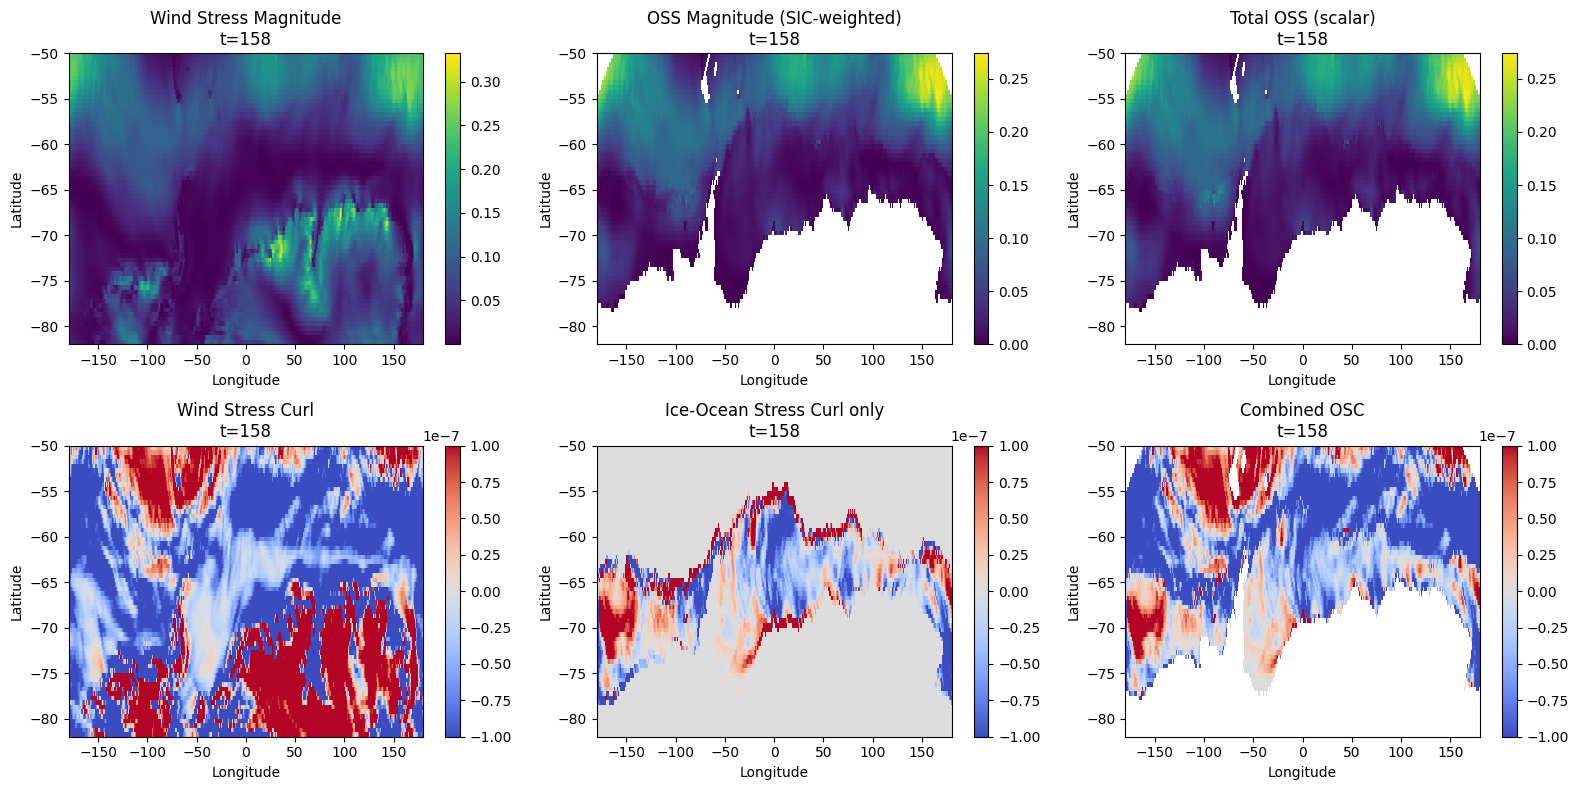

In [16]:
llon, llat = np.meshgrid(lon, lat)
t = 158

# calculate isc for all time steps if not already done
isc = np.zeros((dot.shape[2], dot.shape[1], dot.shape[0]))  # (time, lat, lon)
for tt in range(dot.shape[2]):
    tau_iw_x_t = tau_iw_x[:, :, tt].T
    tau_iw_y_t = tau_iw_y[:, :, tt].T
    tau_iw_x_t = np.where(np.isnan(tau_iw_x_t), 0.0, tau_iw_x_t)
    tau_iw_y_t = np.where(np.isnan(tau_iw_y_t), 0.0, tau_iw_y_t)
    diw_y_dx, _ = grad_sphere(tau_iw_y_t, llon, llat)
    _, diw_x_dy = grad_sphere(tau_iw_x_t, llon, llat)
    isc[tt] = diw_y_dx - diw_x_dy

isc = isc.transpose(2, 1, 0)  # → (lon, lat, time)

# extract time slices → (lat, lon) via .T
ws_t        = np.sqrt(tau_aw_x[:, :, t]**2 + tau_aw_y[:, :, t]**2).T
oss_t       = np.sqrt(oss_x[:, :, t]**2 + oss_y[:, :, t]**2).T
total_oss_t = total_oss[:, :, t].T
wsc_t       = wsc[:, :, t].T
isc_t       = isc[:, :, t].T
osc_t       = osc[:, :, t].T

panels = [
    (ws_t,        'Wind Stress Magnitude',        None,  'viridis'),
    (oss_t,       'OSS Magnitude (SIC-weighted)', None,  'viridis'),
    (total_oss_t, 'Total OSS (scalar)',           None,  'viridis'),
    (wsc_t,       'Wind Stress Curl',             1e-7,  'coolwarm'),
    (isc_t,       'Ice-Ocean Stress Curl only',   1e-7,  'coolwarm'),
    (osc_t,       'Combined OSC',                 1e-7,  'coolwarm'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, (data, title, vlim, cmap) in zip(axes.flatten(), panels):
    if vlim is not None:
        im = ax.pcolormesh(llon, llat, data, vmin=-vlim, vmax=vlim, cmap=cmap, shading='auto')
    else:
        im = ax.pcolormesh(llon, llat, data, cmap=cmap, shading='auto')
    plt.colorbar(im, ax=ax)
    ax.set_title(f'{title}\nt={t}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

## Remove seasonality
Set as `False`:
- Keeps seasonal cycle
- MCA is the full relationship between the forcing and response variables (e.g. WS and SLA)

Set as `True`:
- Removes the seasonal cycle
- MCA highlights interannual variability within the seasons


In [17]:
remove_seas = False
seas_label = 'seasonal anomalies' if remove_seas else 'raw'

n_time, n_lat, n_lon = len(time_coords), len(lat), len(lon)

arrays = {'dot': dot, 'sla': sla, 'sic': sic,
          'total_ws': total_ws, 'wsc': wsc,
          'total_oss': total_oss, 'osc': osc}

if remove_seas:
    for name in arrays:
        arr = arrays[name]
        if arr.shape == (n_lon, n_lat, n_time):
            da = xr.DataArray(arr, dims=['longitude', 'latitude', 'time'],
                              coords={'time': time_coords, 'latitude': lat, 'longitude': lon})
        elif arr.shape == (n_time, n_lat, n_lon):
            da = xr.DataArray(arr, dims=['time', 'latitude', 'longitude'],
                              coords={'time': time_coords, 'latitude': lat, 'longitude': lon})
        arrays[name] = (da.groupby('time.month') - da.groupby('time.month').mean('time')).transpose('longitude', 'latitude', 'time').values
    print("Seasonal cycle removed.")
else:
    print("Skipping seasonal removal.")

# unpack back to individual variables
dot, sla, sic, total_ws, wsc, total_oss, osc = [arrays[k] for k in arrays]

Skipping seasonal removal.


In [18]:
print(total_ws.shape)
print(wsc.shape)
print(total_oss.shape)
print(osc.shape)

(360, 64, 268)
(360, 64, 268)
(360, 64, 268)
(360, 64, 268)


## Remove mean and linear trend


## `detrend3d`

Removes the linear trend and mean from a 3D array of shape `(lon, lat, time)` at every grid point.

### Steps
1. Converts the time coordinate to number of days from the first time step
2. Loops over every `(lon, lat)` grid point and fits a linear regression using `trend_ci`
3. Subtracts the fitted trend (slope × time + intercept) from the original data
4. Returns the detrended array along with the slope and p-value at each grid point

### Inputs
- `var` : xarray DataArray of shape `(lon, lat, time)` with a `time` coordinate

### Outputs
- `var_det` : detrended DataArray, same shape as input
- `slope` : 2D array `(lon, lat)` of trend slopes in units/day
- `pval` : 2D array `(lon, lat)` of p-values for the trend significance

### Notes
- The mean is removed implicitly via the regression intercept
- Grid points with fewer than 2 valid observations are set to NaN

In [19]:
dot_det, _, _ = ft.detrend3d(xr.DataArray(dot, dims=['longitude', 'latitude', 'time'],
                           coords={'time': time_coords, 'latitude': lat, 'longitude': lon}))

sla_det, _, _ = ft.detrend3d(xr.DataArray(sla, dims=['longitude', 'latitude', 'time'],
                           coords={'time': time_coords, 'latitude': lat, 'longitude': lon}))

sic_det, _, _ = ft.detrend3d(xr.DataArray(sic, dims=['longitude', 'latitude', 'time'],
                           coords={'time': time_coords, 'latitude': lat, 'longitude': lon}))

total_ws_det, _, _ = ft.detrend3d(xr.DataArray(total_ws, dims=['longitude', 'latitude', 'time'],
                           coords={'time': time_coords, 'latitude': lat, 'longitude': lon}))

wsc_det, _, _ = ft.detrend3d(xr.DataArray(wsc, dims=['longitude', 'latitude', 'time'],
                           coords={'time': time_coords, 'latitude': lat, 'longitude': lon}))

total_oss_det, _, _ = ft.detrend3d(xr.DataArray(total_oss, dims=['longitude', 'latitude', 'time'],
                           coords={'time': time_coords, 'latitude': lat, 'longitude': lon}))

osc_det, _, _ = ft.detrend3d(xr.DataArray(osc, dims=['longitude', 'latitude', 'time'],
                           coords={'time': time_coords, 'latitude': lat, 'longitude': lon}))


## Maximum Covariance Analysis (MCA)

In [20]:
# define all variables in one place using the detrended variables
var_dict = {
    'dot': dot_det,
    'sla': sla_det,
    'sic': sic_det,
    'total_ws': total_ws_det,
    'wsc': wsc_det,
    'total_oss': total_oss_det,
    'osc': osc_det
}

# choose variables
var_1_name = 'wsc' # forcing field
var_2_name = 'sla' # response field

# look up the arrays/names
var_1 = var_dict[var_1_name]
var_2 = var_dict[var_2_name]

print(f'{var_1_name} shape:', var_1.shape)
print(f'{var_2_name} shape:', var_2.shape)

n_time = len(time_coords)
n_lat = len(lat)
n_lon = len(lon)

# convert to xa_1
if var_1.shape == (n_lon, n_lat, n_time):
    xa_1 = xr.DataArray(var_1, dims=['longitude', 'latitude', 'time'],
                        coords={'time': time_coords, 'latitude': lat, 'longitude': lon})
elif var_1.shape == (n_time, n_lat, n_lon):
    xa_1 = xr.DataArray(var_1, dims=['time', 'latitude', 'longitude'],
                        coords={'time': time_coords, 'latitude': lat, 'longitude': lon})

# create xa_2
if var_2.shape == (n_lon, n_lat, n_time):
    xa_2 = xr.DataArray(var_2, dims=['longitude', 'latitude', 'time'],
                        coords={'time': time_coords, 'latitude': lat, 'longitude': lon})
elif var_2.shape == (n_time, n_lat, n_lon):
    xa_2 = xr.DataArray(var_2, dims=['time', 'latitude', 'longitude'],
                        coords={'time': time_coords, 'latitude': lat, 'longitude': lon})

# transpose both to (time, latitude, longitude)
xa_1 = xa_1.transpose('time', 'latitude', 'longitude')
xa_2 = xa_2.transpose('time', 'latitude', 'longitude')

seamask_xa = xr.DataArray(seamask.T, dims=['latitude', 'longitude'],
                          coords={'latitude': lat, 'longitude': lon})

# apply sea mask
xa_1_masked = xa_1.where(seamask_xa == 1)
xa_2_masked = xa_2.where(seamask_xa == 1)

wsc shape: (360, 64, 268)
sla shape: (360, 64, 268)


In [21]:
# ignore warnings which are xeof bugs/abouts missing values as these are due to the seamask and landmask
warnings.filterwarnings('ignore', category=FutureWarning, message='Deleting a single level of a MultiIndex')
warnings.filterwarnings('ignore', category=RuntimeWarning, message='Degrees of freedom <= 0')
warnings.filterwarnings('ignore', category=UserWarning, message='Dataset has.*components')


# MCA
model = xe.cross.MCA(n_modes=22, standardize=True)
# default is 0.2 (uses 20% of max possible rank)
# try 0.5 or higher if the warning persists
model.fit(xa_1_masked, xa_2_masked, dim='time')
comps1, comps2 = model.components()
scores1, scores2 = model.scores()

s1 = scores1.values; s2 = scores2.values
c1 = comps1.values; c2 = comps2.values

sq_cov_frac = model.squared_covariance_fraction()
sq_cov_percent = sq_cov_frac * 100
for m in range(1, 5):
    print(f"  Mode {m}: {sq_cov_percent.sel(mode=m).values:.2f}%")
cum_sum = np.cumsum(sq_cov_percent)

print('Squared covariance fraction:',sq_cov_percent.values)
print('Cumulative sum of squares:', cum_sum)

  Mode 1: 40.69%
  Mode 2: 28.86%
  Mode 3: 10.11%
  Mode 4: 5.00%
Squared covariance fraction: [40.69486026 28.86051295 10.11267926  5.00168977  3.27664531  2.92288347
  1.80788605  1.61396935  0.88600337  0.76685566  0.58351463  0.48244693
  0.30019352  0.2733082   0.21866147  0.18201669  0.16886201  0.14886456
  0.14308376  0.12904056  0.12124222  0.10574829]
Cumulative sum of squares: <xarray.DataArray 'squared_covariance_fraction' (mode: 22)> Size: 176B
array([40.69486026, 69.5553732 , 79.66805246, 84.66974223, 87.94638754,
       90.86927101, 92.67715706, 94.29112641, 95.17712977, 95.94398543,
       96.52750006, 97.00994699, 97.31014051, 97.58344871, 97.80211018,
       97.98412687, 98.15298888, 98.30185344, 98.4449372 , 98.57397776,
       98.69521998, 98.80096827])
Coordinates:
  * mode     (mode) int64 176B 1 2 3 4 5 6 7 8 9 ... 14 15 16 17 18 19 20 21 22


In [22]:
# calculate different types of correlation (Pearson and Spearman)
r_pears = []; p_pears = []
r_spear = []; p_spear = []
for m in range(1,5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2)); p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2)); p_spear.append(np.round(p, 2))

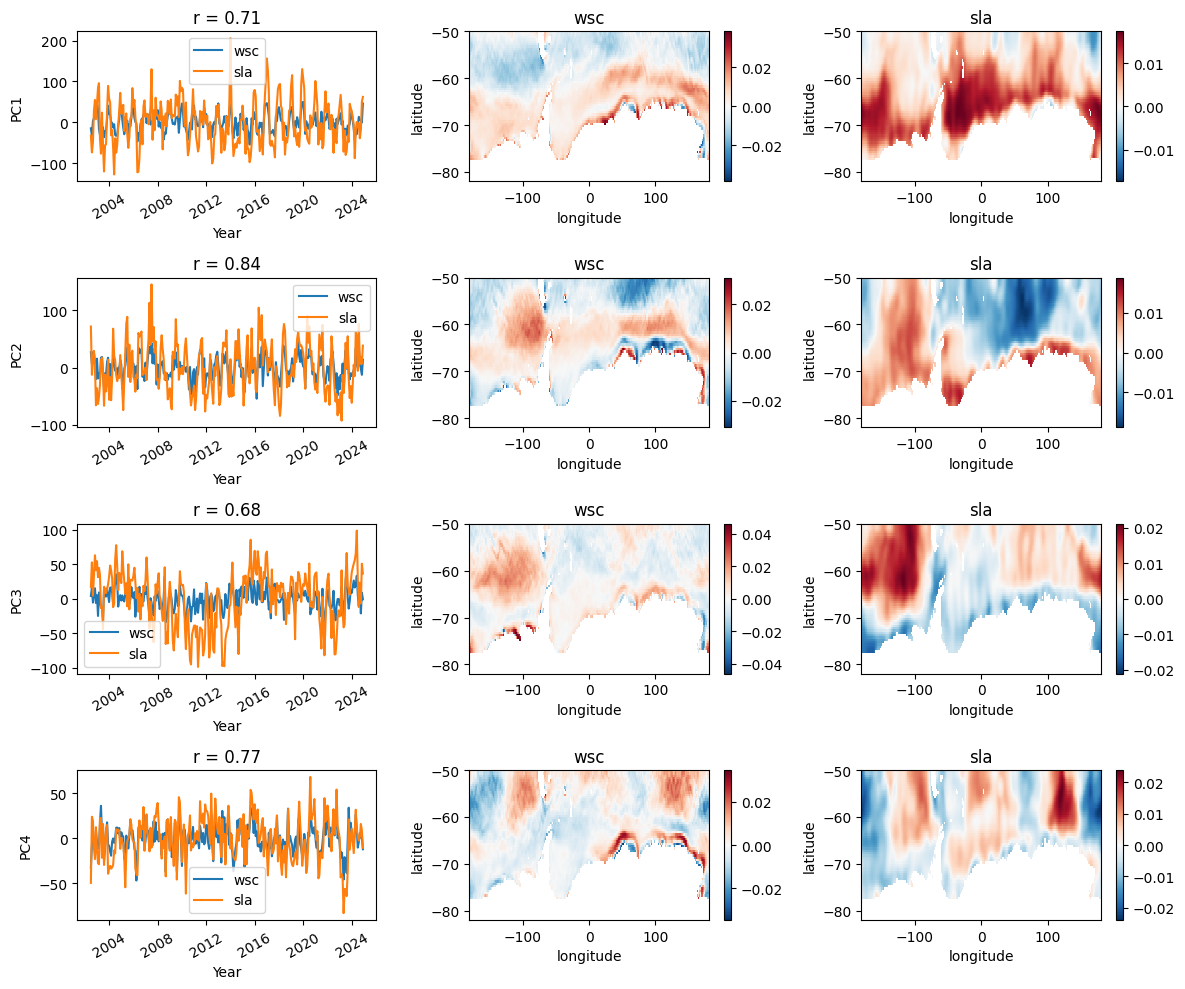

In [23]:
# Plot
fig = plt.figure(figsize=(12,10))

for i in range(0,4):
    j = 3*i+1 # a = 2*(i+1) + i - 1

    plt.subplot(4,3,j)
    scores1.sel(mode=i+1).plot(label = f'{var_1_name}')
    scores2.sel(mode=i+1).plot(label = f'{var_2_name}')
    plt.title('r = ' +str(r_spear[i]))
    plt.xlabel('Year'); plt.ylabel('PC'+str(int(i+1)))
    plt.xticks(rotation=30)
    plt.legend()

    plt.subplot(4,3,j+1)
    comps1.sel(mode=i+1).plot()
    plt.title(f'{var_1_name}')

    plt.subplot(4,3,j+2)
    comps2.sel(mode=i+1).plot()
    plt.title(f'{var_2_name}')

# plt.title(f'MCA: {var_1_name} vs {var_2_name} ({seas_label})')
fig.tight_layout()
#fig.savefig(path + 'results/MCA_output_' + gridtype + '_seas.png')

# Calculate correlation with Climatic Indices

## SAM

SAM times:     816
MCA times:     268
Common times:  268
Subsetted times:  59


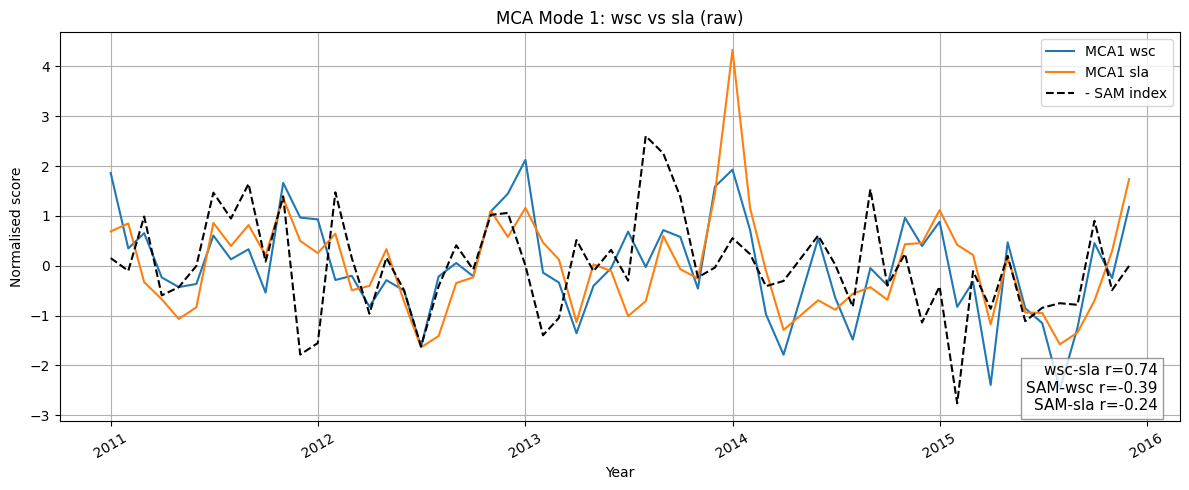

In [25]:
# build SAM as xarray with matching time coords for easy alignment
# sam_time = pd.date_range(start=f'{sam_yrs[0]}-01', periods=len(sam_ind_1d), freq='MS')
# sam_da = xr.DataArray(sam_ind_1d, dims=['time'], coords={'time': sam_time})

# find the common time axis between SAM and MCA scores
common_time = np.intersect1d(sam_da.time.values, scores1.time.values)

print('SAM times:    ', len(sam_da.time.values))
print('MCA times:    ', len(scores1.time.values))
print('Common times: ', len(common_time))

# --- specific time range ---
time_start = '2011-01'
time_end   = '2015-12'
common_time = common_time[(common_time >= np.datetime64(time_start)) &
                           (common_time <= np.datetime64(time_end))]
print('Subsetted times: ', len(common_time))
# --------------------------------------------------

# trim both to common times
sam_norm = sam_da.sel(time=common_time)
sam_norm = (sam_norm - sam_norm.mean()) / sam_norm.std()

pc1_s1 = scores1.sel(mode=1, time=common_time)
pc1_s2 = scores2.sel(mode=1, time=common_time)
pc1_s1_norm = (pc1_s1 - pc1_s1.mean()) / pc1_s1.std()
pc1_s2_norm = (pc1_s2 - pc1_s2.mean()) / pc1_s2.std()

r_12,    _ = scipy.stats.pearsonr(pc1_s1_norm.values, pc1_s2_norm.values)
r_sam_1, _ = scipy.stats.pearsonr(sam_norm.values, pc1_s1_norm.values)
r_sam_2, _ = scipy.stats.pearsonr(sam_norm.values, pc1_s2_norm.values)

# plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(pc1_s1_norm.time, pc1_s1_norm, label=f'MCA1 {var_1_name}')
ax.plot(pc1_s2_norm.time, pc1_s2_norm, label=f'MCA1 {var_2_name}')
ax.plot(sam_norm.time, - sam_norm, label='- SAM index', linestyle='--', color='black')

ax.set_title(f'MCA Mode 1: {var_1_name} vs {var_2_name} ({seas_label})')
ax.set_xlabel('Year')
ax.set_ylabel('Normalised score')
ax.legend()
ax.grid(True)
ax.tick_params(axis='x', rotation=30)

corr_text = (f'{var_1_name}-{var_2_name} r={r_12:.2f}\n'
             f'SAM-{var_1_name} r={r_sam_1:.2f}\n'
             f'SAM-{var_2_name} r={r_sam_2:.2f}')
ax.text(0.98, 0.02, corr_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='grey', alpha=0.8))

fig.tight_layout()
plt.show()

## ENSO/SOI


SOI times:     1800
MCA times:     268
Common times:  59
Subsetted times:  59


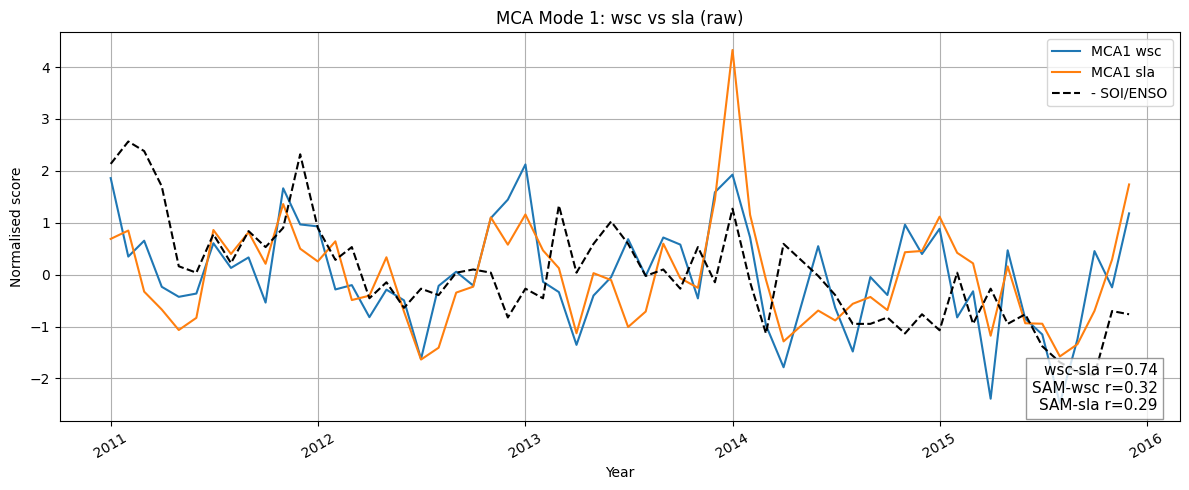

In [29]:
# build SOI as xarray with matching time coords for easy alignment
# soi_time = pd.date_range(start=f'{soi_yrs[0]}-01', periods=len(soi_ind_1d), freq='MS')
# soi_da = xr.DataArray(soi_ind_1d, dims=['time'], coords={'time': soi_time})

# find the common time axis between SOI and MCA scores
common_time_soi_ds = np.intersect1d(soi_da.time.values, scores1.time.values)

print('SOI times:    ', len(soi_da.time.values))
print('MCA times:    ', len(scores1.time.values))
print('Common times: ', len(common_time))

# --- specific time range ---
time_start = '2003-01'
time_end   = '2024-12'
common_time = common_time[(common_time >= np.datetime64(time_start)) &
                           (common_time <= np.datetime64(time_end))]
print('Subsetted times: ', len(common_time))
# --------------------------------------------------

# trim both to common times
soi_norm = soi_da.sel(time=common_time)
soi_norm = (soi_norm - soi_norm.mean()) / soi_norm.std()

pc1_s1 = scores1.sel(mode=1, time=common_time)
pc1_s2 = scores2.sel(mode=1, time=common_time)
pc1_s1_norm = (pc1_s1 - pc1_s1.mean()) / pc1_s1.std()
pc1_s2_norm = (pc1_s2 - pc1_s2.mean()) / pc1_s2.std()

r_12,    _ = scipy.stats.pearsonr(pc1_s1_norm.values, pc1_s2_norm.values)
r_sam_1, _ = scipy.stats.pearsonr(soi_norm.values, pc1_s1_norm.values)
r_sam_2, _ = scipy.stats.pearsonr(soi_norm.values, pc1_s2_norm.values)

# plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(pc1_s1_norm.time, pc1_s1_norm, label=f'MCA1 {var_1_name}')
ax.plot(pc1_s2_norm.time, pc1_s2_norm, label=f'MCA1 {var_2_name}')
ax.plot(soi_norm.time, soi_norm, label='- SOI/ENSO', linestyle='--', color='black')

ax.set_title(f'MCA Mode 1: {var_1_name} vs {var_2_name} ({seas_label})')
ax.set_xlabel('Year')
ax.set_ylabel('Normalised score')
ax.legend()
ax.grid(True)
ax.tick_params(axis='x', rotation=30)

corr_text = (f'{var_1_name}-{var_2_name} r={r_12:.2f}\n'
             f'SOI-{var_1_name} r={r_sam_1:.2f}\n'
             f'SOI-{var_2_name} r={r_sam_2:.2f}')
ax.text(0.98, 0.02, corr_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='grey', alpha=0.8))

fig.tight_layout()
plt.show()